In [452]:
import torch
import torch.nn as nn

In [453]:
x = torch.randn(1, 1024, 1024, 3)
x = x.transpose(1,-1)
x.shape

torch.Size([1, 3, 1024, 1024])

In [454]:
embed = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=16, stride=16)
x = embed(x)
x.shape

torch.Size([1, 768, 64, 64])

In [455]:
3*1024*1024

3145728

In [456]:
64*64*768

3145728

In [457]:
m = nn.Conv2d(16, 33, 3, stride=2)
input = torch.randn(20, 16, 50, 100)
print(input.shape)
output = m(input)
print(output.shape)

torch.Size([20, 16, 50, 100])
torch.Size([20, 33, 24, 49])


In [458]:
class PatchEmbed(nn.Module):
    def __init__(self, in_chans: int = 3, embed_dim: int = 768, kernel_size: int = 16, stride: int = 16):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size, stride)

    def forward(self, x):
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1)
        return x
    
x = torch.randn(1, 3, 1024, 1024)
pe = PatchEmbed()
print(pe(x).shape)

torch.Size([1, 64, 64, 768])


In [459]:
class MLPBlock(nn.Module):
    def __init__(self, embedding_dim: int, mlp_dim: int):
        super().__init__()
        self.lin1 = nn.Linear(embedding_dim, mlp_dim)     
        self.lin2 = nn.Linear(mlp_dim, embedding_dim) 
        self.act = nn.GELU()

    def forward(self, x):
        return self.lin2(self.act(self.lin1(x)))
    

class LayerNorm2d(nn.Module):
    def __init__(self, num_channels: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.eps = eps

    def forward(self, x):
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        x = (x - u) / torch.sqrt(s + self.eps)
        x = self.weight[:, None, None] * x + self.bias[:, None, None]
        return x


x = torch.randn(2, 256, 64, 64)
ln = LayerNorm2d(256)
print(ln(x).shape)  

y = torch.randn(2, 100, 768)
mlp = MLPBlock(768, 3072)
print(mlp(y).shape)

torch.Size([2, 256, 64, 64])
torch.Size([2, 100, 768])


In [460]:
class SelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int = 8, qkv_bias: bool = True):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv_bias: bool = qkv_bias
        self.qkv = nn.Linear(dim, dim*3,bias=self.qkv_bias)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B = x.shape[0]
        H = x.shape[1]
        W = x.shape[2]
        x = self.qkv(x)
        x = x.reshape(B, H*W, 3, self.num_heads, -1)
        x = x.permute(2, 0, 3, 1, 4)
        q, k, v = x.unbind(0)
        
        q = q.reshape(B*self.num_heads, H*W, self.head_dim)
        k = k.reshape(B*self.num_heads, H*W, self.head_dim)
        v = v.reshape(B*self.num_heads, H*W, self.head_dim)

        attn = (q * self.scale) @ k.transpose(-2, -1)
        attn = torch.softmax(attn, dim=-1)
        x = attn @ v
        x = x.reshape(B, self.num_heads, H, W, self.head_dim).permute(0, 2, 3, 1, 4).reshape(B, H, W, -1) 
        x = self.proj(x)
        return x
    

x = torch.randn(1, 64, 64, 768)
attn = SelfAttention(dim=768, num_heads=12)
print(attn(x).shape)

torch.Size([1, 64, 64, 768])


In [461]:
m = nn.Linear(20, 30)
input = torch.randn(128, 20)
print(input.shape)
output = m(input)
print(output.shape)

torch.Size([128, 20])
torch.Size([128, 30])


In [462]:
z = torch.randn(1, 64, 64, 768)
print(z.shape)
qkv = nn.Linear(768, 768*3,bias=True)
z = qkv(z)
print(z.shape)
z = z.reshape(1, 64*64, 3, 8, -1)
print(z.shape)
z = z.permute(2, 0, 3, 1, 4)
print(z.shape)
q,k,v = z.unbind(0)
print(f"{q.shape}, {k.shape}, {v.shape}")

torch.Size([1, 64, 64, 768])
torch.Size([1, 64, 64, 2304])
torch.Size([1, 4096, 3, 8, 96])
torch.Size([3, 1, 8, 4096, 96])
torch.Size([1, 8, 4096, 96]), torch.Size([1, 8, 4096, 96]), torch.Size([1, 8, 4096, 96])


In [463]:
q = q.reshape(1*8, 64*64, 96)
k = k.reshape(1*8, 64*64, 96)
v = v.reshape(1*8, 64*64, 96)
print(q.shape)

torch.Size([8, 4096, 96])


In [464]:
attn = (q * (96**-0.5)) @ k.transpose(-2, -1)
print(q.shape)
print(attn.shape)
attn = torch.softmax(attn, dim=-1)
print(attn.shape)
x = attn @ v
print(x.shape)

torch.Size([8, 4096, 96])
torch.Size([8, 4096, 4096])
torch.Size([8, 4096, 4096])
torch.Size([8, 4096, 96])


In [465]:
import torch.nn.functional as F
def get_rel_pos(q_size: int, k_size: int, rel_pos: torch.Tensor) -> torch.Tensor:
    """
    Get relative positional embeddings according to the relative positions of
        query and key sizes.
    Args:
        q_size: size of the query q
        k_size: size of the key k
        rel_pos(Tensor): the learnable table, relative position embeddings (L, C).

    Returns:
        Extracted positional embeddings according to relative positions.
    """

    # 1. The table must have 2*max(q_size, k_size) - 1 rows. If not, interpolate.
    max_rel_dist = 2 * max(q_size, k_size) - 1
    if rel_pos.shape[0] != max_rel_dist:
        # interpolate rel_pos to the right number of rows
        # rel_pos.shape[0] = L
        rel_pos_resized = F.interpolate(
            rel_pos.reshape(1, rel_pos.shape[0], -1).permute(0, 2, 1), # (rel_pos.shape[0], head_dim) -> (1, L, head_dim) -> (1, head_dim, L)
            size=max_rel_dist,
            mode="linear",
        ) # (1, head_dim, L) -> (1, head_dim, max_rel_dist)
        rel_pos_resized = rel_pos_resized.reshape(-1, max_rel_dist).permute(1, 0) # (1, head_dim, max_rel_dist) -> (head_dim, max_rel_dist) -> (max_rel_dist, head_dim)
    else:
        # (max_rel_dist, head_dim)
        rel_pos_resized = rel_pos

    # 2. Build query and key coordinate vectors, scaled if sizes differ.
    q_coords = torch.arange(q_size)[:, None] * max(k_size / q_size, 1.0) # (q_size, 1)
    k_coords = torch.arange(k_size)[None, :] * max(q_size / k_size, 1.0) # (1, k_size)

    # 3. Relative coords -> table indices (shift to be non-negative).
    # (q_size, 1) - (1, k_size) -> gets broadcasted -> (q_size, k_size)
    relative_coords = (q_coords - k_coords) + (k_size - 1) * max(q_size / k_size, 1.0)

    # 4. Gather the rows.
    return rel_pos_resized[relative_coords.long()] # (q_size, k_size, head_dim)

In [466]:
head_dim = 2
L = 2 * 3 - 1   # = 5, for a size-3 axis
rel_pos = torch.arange(L * head_dim).float().reshape(L, head_dim)  # readable table
print(f"rel_pos {rel_pos}")
print(rel_pos.shape)
out = get_rel_pos(2, 2, rel_pos)
print(out.shape)   # expect (3, 3, 2)
print(out[:, :, 0]) 

rel_pos tensor([[0., 1.],
        [2., 3.],
        [4., 5.],
        [6., 7.],
        [8., 9.]])
torch.Size([5, 2])
torch.Size([2, 2, 2])
tensor([[4.0000, 0.6667],
        [7.3333, 4.0000]])


In [467]:
from typing import Tuple, Optional
def add_decomposed_rel_pos(
    attn: torch.Tensor,
    q: torch.Tensor,
    rel_pos_h: torch.Tensor,
    rel_pos_w: torch.Tensor,
    q_size: Tuple[int, int],
    k_size: Tuple[int, int] 
) -> torch.Tensor:
    """
    Calculate decomposed Relative Positional Embeddings 
    Args:
        attn (Tensor): attention map. (B*num_heads, q_h*q_w, k_h*k_w)
        q (Tensor): query q in the attention layer with shape (B, q_h * q_w, C or head_dim).
        rel_pos_h (Tensor): relative position embeddings (Lh, C) for height axis.
        rel_pos_w (Tensor): relative position embeddings (Lw, C) for width axis.
        q_size (Tuple): spatial sequence size of query q with (q_h, q_w).
        k_size (Tuple): spatial sequence size of key k with (k_h, k_w).
    Returns:
        attn (Tensor): attention map with added relative positional embeddings.
    """
    q_h, q_w = q_size
    k_h, k_w = k_size
    
    Rh = get_rel_pos(q_h, k_h, rel_pos_h) # (q_h, k_h, head_dim)
    Rw = get_rel_pos(q_w, k_w, rel_pos_w) # (q_w, k_w, head_dim)

    B, _, h_dim = q.shape 
    r_q = q.reshape(B, q_h, q_w, h_dim) # (B, q_h*q_w, head_dim) -> (B, q_h, q_w, head_dim)
    rel_h = torch.einsum("bhwc,hkc->bhwk", r_q, Rh)   # (B*num_heads, q_h, q_w, head_dim), (q_h,k_h,head_dim) -> (B*num_heads, q_h, q_w, k_h)
    rel_w = torch.einsum("bhwc,wkc->bhwk", r_q, Rw)   # (B*num_heads, q_h, q_w, head_dim), (q_w,k_w,head_dim) -> (B*num_heads, q_h, q_w, k_w)

    attn = (
        attn.view(B, q_h, q_w, k_h, k_w) # (B*num_heads, q_h*q_w, k_h*k_w) -> (B*num_heads, q_h, q_w, k_h, k_w)
        + rel_h[:, :, :, :, None] # (B*num_heads,q_h,q_w,k_h) -> (B*num_heads,q_h,q_w,k_h,1), broadcasts over k_w
        + rel_w[:, :, :, None, :] # (B*num_heads,q_h,q_w,k_w) -> (B*num_heads,q_h,q_w,1,k_w), broadcasts over k_h
    ).view(B, q_h * q_w, k_h * k_w) # back to (B*num_heads, q_h*q_w, k_h*k_w)


    return attn


In [468]:
class SelfAttention(nn.Module):
    """Multi-head Attention block with relative position embeddings."""
    def __init__(
        self, 
        dim: int, 
        num_heads: int = 8, 
        qkv_bias: bool = True, 
        use_rel_pos: bool = False,
        rel_pos_zero_init: bool = True,
        input_size: Optional[Tuple[int, int]]=None
    ) -> None:
        """
        Args:
            dim (int): Number of input channels.
            num_heads (int): Number of attention heads.
            qkv_bias (bool):  If True, add a learnable bias to query, key, value.
            rel_pos (bool): If True, add relative positional embeddings to the attention map.
            rel_pos_zero_init (bool): If True, zero initialize relative positional parameters.
            input_size (tuple(int, int) or None): Input resolution for calculating the relative
                positional parameter size.
        """
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
    
        # (B, H/16, W/16, embed_dim) -> (B, H/16, W/16, 3 * embed_dim)
        self.qkv = nn.Linear(dim, dim*3,bias=qkv_bias)
        # (B, H/16, W/16, embed_dim) -> (B, H/16, W/16, embed_dim)
        self.proj = nn.Linear(dim, dim)

        self.use_rel_pos = use_rel_pos
        if self.use_rel_pos:
            assert(
                input_size is not None
            ), "Input size must be provided if using relative positional encoding."
            # initialize relative positional embeddings
            self.rel_pos_h = nn.Parameter(torch.zeros(2 * input_size[0] - 1, self.head_dim))
            self.rel_pos_w = nn.Parameter(torch.zeros(2 * input_size[1] - 1, self.head_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, H, W, _ = x.shape
        # (B, H/16, W/16, embed_dim) -> (B, H/16, W/16, 3 * embed_dim)
        qkv = self.qkv(x)
        # (B, H/16, W/16, 3 * embed_dim) -> (B, H/16*W/16, 3, num_heads, embed_dim/num_heads)
        qkv = qkv.reshape(B, H*W, 3, self.num_heads, -1)
        # (B, H/16*W/16, 3, num_heads, embed_dim/num_heads) -> (3, B, num_heads, H/16*W/16, embed_dim/num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        # (B, H/16*W/16, 3, num_heads, embed_dim/num_heads) -> (B, num_heads, H/16*W/16, embed_dim/num_heads) each
        q, k, v = qkv.unbind(0)
        
        # (1, B, num_heads, H/16*W/16, embed_dim/num_heads) -> (B*num_heads, H/16*W/16, embed_dim/num_heads)
        q = q.reshape(B*self.num_heads, H*W, self.head_dim)
        # (1, B, num_heads, H/16*W/16, embed_dim/num_heads) -> (B*num_heads, H/16*W/16, embed_dim/num_heads)
        k = k.reshape(B*self.num_heads, H*W, self.head_dim)
        # (1, B, num_heads, H/16*W/16, embed_dim/num_heads) -> (B*num_heads, H/16*W/16, embed_dim/num_heads)
        v = v.reshape(B*self.num_heads, H*W, self.head_dim)

        # (B*num_heads, H/16*W/16, embed_dim/num_heads) * (B*num_heads, embed_dim/num_heads, H/16*W/16) -> (B*num_heads, H/16*W/16, H/16*W/16)
        attn = (q * self.scale) @ k.transpose(-2, -1)

        if self.use_rel_pos:
            attn = add_decomposed_rel_pos(attn, q, self.rel_pos_h, self.rel_pos_w, (H, W), (H, W))
            
        # (B*num_heads, H/16*W/16, H/16*W/16) -> (B*num_heads, H/16*W/16, H/16*W/16)
        attn = torch.softmax(attn, dim=-1)
        x = attn @ v
        # (B*num_heads, H/16*W/16, embed_dim/num_heads) -> (B, num_heads, H/16, W/16, embed_dim/num_heads) -> (B, H/16, W/16, num_heads, embed_dim/num_heads)
        # (B, H/16, W/16, num_heads, embed_dim/num_heads) -> (B, H/16, W/16, embed_dim)
        x = x.reshape(B, self.num_heads, H, W, self.head_dim).permute(0, 2, 3, 1, 4).reshape(B, H, W, -1) 
        # (B, H/16, W/16, embed_dim) -> (B, H/16, W/16, embed_dim)
        x = self.proj(x)
        return x
    

In [469]:
attn = SelfAttention(dim=768, num_heads=12, use_rel_pos=True, input_size=(64, 64))
x = torch.randn(1, 64, 64, 768)
print(attn(x).shape) 

torch.Size([1, 64, 64, 768])


In [470]:
def window_partition(x: torch.Tensor, window_size: int) -> Tuple[torch.Tensor, Tuple[int, int]]:
    """
    Partition into non-overlapping windows with padding if needed.
    Args:
        x (tensor): input tokens with [B, H, W, C].
        window_size (int): window size.
    Returns:
        windows: windows after partition with [B * num_windows, window_size, window_size, C].
        (Hp, Wp): padded height and width before partition
    """
    # H,W = 64  window_size = 14
    B, H, W, C = x.shape
    pad_h = (window_size - H % window_size) % window_size
    pad_w = (window_size - W % window_size) % window_size
    
    if pad_h > 0 or pad_w > 0:
        x = F.pad(x, (0, 0, 0, pad_h, 0, pad_w))

    Hp, Wp = H + pad_h, W + pad_w
    
    x = x.view(B, Hp//window_size, window_size, Wp//window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows, (Hp, Wp)

In [471]:
x = torch.randn(1, 64, 64, 768)
windows, (Hp, Wp) = window_partition(x, window_size=14)
print(windows.shape)   
print(Hp, Wp)   

torch.Size([25, 14, 14, 768])
70 70


In [472]:
def window_unpartition(
    windows: torch.Tensor, window_size: int, pad_hw: Tuple[int, int], hw: Tuple[int, int]
) -> torch.Tensor:
    """
    Window unpartition into original sequences and removing padding.
    Args:
        windows (tensor): input tokens with [B * num_windows, window_size, window_size, C].
        window_size (int): window size.
        pad_hw (Tuple): padded height and width (Hp, Wp).
        hw (Tuple): original height and width (H, W) before padding.
    Returns:
        x: unpartitioned sequences with [B, H, W, C].
    """
    # windows: (B*num_windows, ws, ws, C)   e.g. (25, 14, 14, 768)
    Hp, Wp = pad_hw # 70, 70
    H, W = hw  # 64, 64
    # 25 // (70*70 // 14 // 14) = 25 // 25 = 1
    B = windows.shape[0] // (Hp * Wp // window_size // window_size)
    x = windows.view(B, Hp // window_size, Wp // window_size, window_size, window_size, -1)
    # (B*num_windows, ws, ws, C) -> (B, Hp/ws, Wp/ws, ws, ws, C)   e.g. (1, 5, 5, 14, 14, 768)

    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, Hp, Wp, -1)
    # permute: (B, Hp/ws, Wp/ws, ws, ws, C) -> (B, Hp/ws, ws, Wp/ws, ws, C)   e.g. (1,5,14,5,14,768)
    # view:    (B, Hp/ws, ws, Wp/ws, ws, C) -> (B, Hp, Wp, C)                 e.g. (1, 70, 70, 768)

    if Hp > H or Wp > W:
        x = x[:, :H, :W, :].contiguous()
        # crop back to original size: (B, Hp, Wp, C) -> (B, H, W, C)   e.g. (1, 70, 70, 768) -> (1, 64, 64, 768)

    return x

In [473]:
x_back = window_unpartition(windows, 14, (Hp, Wp), (64, 64))
print(x_back.shape)
print(torch.allclose(x, x_back))

torch.Size([1, 64, 64, 768])
True


In [474]:
class Block(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int,
        mlp_ratio: float = 4.0,
        qkv_bias: bool = True,
        norm_layer: Type[nn.Module] = nn.LayerNorm,
        act_layer: Type[nn.Module] = nn.GELU,
        use_rel_pos: bool = False,
        rel_pos_zero_init: bool = True,
        window_size: int = 0,
        input_size: Optional[Tuple[int, int]] = None,
    ) -> None:
        """
        Args:
            dim (int): Number of input channels.
            num_heads (int): Number of attention heads in each ViT block.
            mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
            qkv_bias (bool): If True, add a learnable bias to query, key, value.
            norm_layer (nn.Module): Normalization layer.
            act_layer (nn.Module): Activation layer.
            use_rel_pos (bool): If True, add relative positional embeddings to the attention map.
            rel_pos_zero_init (bool): If True, zero initialize relative positional parameters.
            window_size (int): Window size for window attention blocks. If it equals 0, then
                use global attention.
            input_size (tuple(int, int) or None): Input resolution for calculating the relative
                positional parameter size.
        """
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = SelfAttention(
            dim,
            num_heads=num_heads,
            use_rel_pos=use_rel_pos,
            rel_pos_zero_init=rel_pos_zero_init,
            input_size=input_size if window_size == 0 else (window_size, window_size),
        )
        self.norm2 = norm_layer(dim)
        self.mlp = MLPBlock(embedding_dim=dim, mlp_dim=int(dim * mlp_ratio), act=act_layer)

        self.window_size = window_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, H, W, C)   e.g. global block (1, 64, 64, 768)  
        shortcut = x
        x = self.norm1(x)

        # Windown partition
        if self.window_size > 0:
            H, W = x.shape[1], x.shape[2]
            x, pad_hw = window_partition(x, self.window_size)
            # (B, H, W, C) -> (B*num_windows, ws, ws, C)   e.g. (1,64,64,768) -> (25,14,14,768)

        x = self.attn(x)
        # windowed: (B*num_windows, ws, ws, C) -> (B*num_windows, ws, ws, C)   e.g. (25,14,14,768)
        # global:   (B, H, W, C) -> (B, H, W, C)                                e.g. (1,64,64,768)

        # Reverse window partition
        if self.window_size > 0:
            x = window_unpartition(x, self.window_size, pad_hw, (H, W))
            # (B*num_windows, ws, ws, C) -> (B, H, W, C)   e.g. (25,14,14,768) -> (1,64,64,768)

        x = x + shortcut
        x = x + self.mlp(self.norm2(x))
        # norm2: (B,H,W,C)->(B,H,W,C)
        # mlp:   (B,H,W,C)->(B,H,W,4C)->(B,H,W,C)     (mlp_ratio=4.0 expands then contracts)
        # residual 2: (B, H, W, C)
        return x # (B, H, W, C) 


In [475]:
class MLPBlock(nn.Module):
    def __init__(
        self, 
        embedding_dim: int, 
        mlp_dim: int,
        act: Type[nn.Module] = nn.GELU
    ) -> None:
        super().__init__()
        self.lin1 = nn.Linear(embedding_dim, mlp_dim)
        self.lin2 = nn.Linear(mlp_dim, embedding_dim)
        self.act = act()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.lin2(self.act(self.lin1(x)))
    

class LayerNorm2d(nn.Module):
    def __init__(
        self, 
        num_channels: int, 
        eps: float = 1e-6
    ) -> None:
        super().__init__()
        self.weight = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        x = (x - u) / torch.sqrt(s + self.eps)
        x = self.weight[:, None, None] * x + self.bias[:, None, None]
        return x

In [476]:

block = Block(dim=768, num_heads=12, window_size=0, use_rel_pos=True, input_size=(64,64))
x = torch.randn(1, 64, 64, 768)
print(block(x).shape) 

torch.Size([1, 64, 64, 768])


In [477]:
class ImageEncoderViT(nn.Module):
    def __init__(
        self,
        img_size: int = 1024,
        patch_size: int = 16,
        in_chans: int = 3,
        embed_dim: int = 768,
        depth: int = 12,
        num_heads: int = 12,
        mlp_ratio: int = 4.0,
        out_chans: int = 256,
        qkv_bias: bool = True,
        norm_layer: Type[nn.Module] = nn.LayerNorm,
        act_layer: Type[nn.Module] = nn.GELU,
        use_abs_pos: bool = True,
        use_rel_pos: bool = False,
        rel_pos_zero_init: bool = True,
        window_size: int = 0,
        global_attn_indexes: Tuple[int, ...] = (),
    ) -> None:
        """
        Args:
            img_size (int): Input image size.
            patch_size (int): Patch size.
            in_chans (int): Number of input image channels.
            embed_dim (int): Patch embedding dimension.
            depth (int): Depth of ViT.
            num_heads (int): Number of attention heads in each ViT block.
            mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
            qkv_bias (bool): If True, add a learnable bias to query, key, value.
            norm_layer (nn.Module): Normalization layer.
            act_layer (nn.Module): Activation layer.
            use_abs_pos (bool): If True, use absolute positional embeddings.
            use_rel_pos (bool): If True, add relative positional embeddings to the attention map.
            rel_pos_zero_init (bool): If True, zero initialize relative positional parameters.
            window_size (int): Window size for window attention blocks.
            global_attn_indexes (list): Indexes for blocks using global attention.
        """
        super().__init__()
        self.img_size = img_size

        self.patch_embed = PatchEmbed(
            kernel_size=(patch_size, patch_size),
            stride=(patch_size, patch_size),
            in_chans=in_chans,
            embed_dim=embed_dim,
        )

        self.pos_embed: Optional[nn.Parameter] = None
        if use_abs_pos:
            # Initialize absolute positional embedding with pretrain image size.
            self.pos_embed = nn.Parameter(
                torch.zeros(1, img_size // patch_size, img_size // patch_size, embed_dim)
            )

        self.blocks = nn.ModuleList()
        for i in range(depth):
            block = Block(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                norm_layer=norm_layer,
                act_layer=act_layer,
                use_rel_pos=use_rel_pos,
                rel_pos_zero_init=rel_pos_zero_init,
                window_size=window_size if i not in global_attn_indexes else 0,
                input_size=(img_size // patch_size, img_size // patch_size),
            )
            self.blocks.append(block)

        self.neck = nn.Sequential(
            nn.Conv2d(
                embed_dim,
                out_chans,
                kernel_size=1,
                bias=False,
            ),
            LayerNorm2d(out_chans),
            nn.Conv2d(
                out_chans,
                out_chans,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            LayerNorm2d(out_chans),
        )


    def forward(self, x:torch.Tensor) -> torch.Tensor:
        # x: (B, 3, 1024, 1024)
        x = self.patch_embed(x)
        # (B, 3, 1024, 1024) -> (B, 64, 64, 768)     conv stride-16, then permute to channels-last

        if self.pos_embed is not None:
            x = x + self.pos_embed
            # (B, 64, 64, 768) + (1, 64, 64, 768) -> (B, 64, 64, 768)   broadcasts over batch

        for block in self.blocks:
            x = block(x)
            # (B, 64, 64, 768) -> (B, 64, 64, 768), repeated 12 times
            # 8 of these run windowed (14x14 windows internally), 4 run global (full 64x64)

        x = self.neck(x.permute(0, 3, 1, 2))
        # permute: (B, 64, 64, 768) -> (B, 768, 64, 64)     channels-last -> channels-first
    # neck:    (B, 768, 64, 64) -> (B, 256, 64, 64)     1x1 conv (768->256) + 3x3 conv (256->256), each + LayerNorm2d

        return x # (B, 256, 64, 64) 


In [478]:
encoder = ImageEncoderViT(
    img_size=1024,
    patch_size=16,
    in_chans=3,
    embed_dim=768,
    depth=12,
    num_heads=12,
    mlp_ratio=4.0,
    out_chans=256,
    qkv_bias=True,
    use_abs_pos=True,
    use_rel_pos=True,
    window_size=14,
    global_attn_indexes=(2, 5, 8, 11),   # SAM's actual ViT-B config
)
encoder = encoder.cuda()
x = torch.randn(1, 3, 1024, 1024)
x = x.cuda()
out = encoder(x)
print(out.shape)  

torch.Size([1, 256, 64, 64])


In [479]:
n_params = sum(p.numel() for p in encoder.parameters())
print(f"{n_params/1e6:.1f}M parameters")   

89.7M parameters


In [480]:
import numpy as np 
np.pi

3.141592653589793

In [481]:
import numpy as np

from typing import Optional, Any
class PositionEmbeddingRandom(nn.Module):
    """
    Positional encoding using random spatial frequencies.
    """
    def __init__(self, num_pos_feats: int = 64, scale: Optional[float] = None) -> None:
        super().__init__()
        if scale is None or scale <= 0.0:
            scale = 1.0
        self.register_buffer(
            "positional_encoding_gaussian_matrix",
            scale * torch.randn((2, num_pos_feats)),
        ) # (2, num_pos_feats)

    def _pe_encoding(self, coords: torch.Tensor) -> torch.Tensor:
        """Positionally encode points that are normalized to [0,1]."""
        coords = 2*coords - 1 # [0,1] -> [-1,1]
        coords = coords @ self.positional_encoding_gaussian_matrix # (...,2) @ (2,num_pos_feats) -> (...,num_pos_feats)
        coords = 2 * np.pi * coords
        return torch.cat([torch.sin(coords), torch.cos(coords)], dim=-1)
    
    def forward(self, size: Tuple[int, int]) -> torch.Tensor:
        """Generate positional encoding for a grid of the specified size."""
        h, w = size
        device: Any = self.positional_encoding_gaussian_matrix.device
        grid = torch.ones((h, w), device=device, dtype=torch.float32)
        y_embed = grid.cumsum(dim=0) - 0.5
        x_embed = grid.cumsum(dim=1) - 0.5
        y_embed = y_embed / h
        x_embed = x_embed / w

        pe = self._pe_encoding(torch.stack([x_embed, y_embed], dim=-1))
        # (h, w, 2) -> (h, w, 2*num_pos_feats)
        return pe.permute(2, 0, 1)  # C x H x W
    
    def forward_with_coords(
        self, coords_input: torch.Tensor, image_size: Tuple[int, int]
    ) -> torch.Tensor:
        """Positionally encode points that are not normalized to [0,1]."""
        coords = coords_input.clone()
        coords[:, :, 0] = coords[:, :, 0] / image_size[1]
        coords[:, :, 1] = coords[:, :, 1] / image_size[0]
        return self._pe_encoding(coords.to(torch.float))  # B x N x C

In [482]:
pe = PositionEmbeddingRandom(num_pos_feats=64)
coords = torch.tensor([[0.5, 0.75]])   # one point, shape (1, 2)
out = pe._pe_encoding(coords)
print(out.shape)

torch.Size([1, 128])


In [483]:
grid_pe = pe.forward((64, 64))
print(grid_pe.shape)  

torch.Size([128, 64, 64])


In [484]:
positional_encoding_gaussian_matrix_new = torch.randn((2, 64))
device: Any = positional_encoding_gaussian_matrix_new.device
grid = torch.ones((4, 4), device=device, dtype=torch.float32)
print(grid, grid.shape)
y_embed = grid.cumsum(dim=0) - 0.5
print(y_embed, y_embed.shape)
x_embed = grid.cumsum(dim=1) - 0.5
print(x_embed, x_embed.shape)
y_embed = y_embed / 4
x_embed = x_embed / 4
print(x_embed, x_embed.shape)
print(y_embed, y_embed.shape)

pe = PositionEmbeddingRandom(num_pos_feats=64)
pe = pe._pe_encoding(torch.stack([x_embed, y_embed], dim=-1))
pe.permute(2, 0, 1).shape

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]) torch.Size([4, 4])
tensor([[0.5000, 0.5000, 0.5000, 0.5000],
        [1.5000, 1.5000, 1.5000, 1.5000],
        [2.5000, 2.5000, 2.5000, 2.5000],
        [3.5000, 3.5000, 3.5000, 3.5000]]) torch.Size([4, 4])
tensor([[0.5000, 1.5000, 2.5000, 3.5000],
        [0.5000, 1.5000, 2.5000, 3.5000],
        [0.5000, 1.5000, 2.5000, 3.5000],
        [0.5000, 1.5000, 2.5000, 3.5000]]) torch.Size([4, 4])
tensor([[0.1250, 0.3750, 0.6250, 0.8750],
        [0.1250, 0.3750, 0.6250, 0.8750],
        [0.1250, 0.3750, 0.6250, 0.8750],
        [0.1250, 0.3750, 0.6250, 0.8750]]) torch.Size([4, 4])
tensor([[0.1250, 0.1250, 0.1250, 0.1250],
        [0.3750, 0.3750, 0.3750, 0.3750],
        [0.6250, 0.6250, 0.6250, 0.6250],
        [0.8750, 0.8750, 0.8750, 0.8750]]) torch.Size([4, 4])


torch.Size([128, 4, 4])

In [485]:
pe = PositionEmbeddingRandom(num_pos_feats=64)
coords = torch.tensor([[[512.0, 300.0], [100.0, 900.0]]])  # (1, 2, 2)
out = pe.forward_with_coords(coords, image_size=(1024, 1024))
print(out.shape)  

torch.Size([1, 2, 128])


In [486]:
points = torch.tensor([[[512.0, 300.0], [100.0, 900.0]]])   
labels = torch.tensor([[1, 0]])                             

In [487]:
class PromptEncoder(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        image_embedding_size: Tuple[int, int],
        input_image_size: Tuple[int, int],
        mask_in_chans: int,
        activation: Type[nn.Module] = nn.GELU,
    ) -> None:
        """
        Encodes prompts for input to SAM's mask decoder.

        Arguments:
          embed_dim (int): The prompts' embedding dimension
          image_embedding_size (tuple(int, int)): The spatial size of the
            image embedding, as (H, W).
          input_image_size (int): The padded size of the image as input
            to the image encoder, as (H, W).
          mask_in_chans (int): The number of hidden channels used for
            encoding input masks.
          activation (nn.Module): The activation to use when encoding
            input masks.
        """
        super().__init__()
        self.embed_dim = embed_dim
        self.input_image_size = input_image_size
        self.image_embedding_size = image_embedding_size
        self.pe_layer = PositionEmbeddingRandom(embed_dim//2)

        self.num_point_embeddings: int = 4  # pos/neg point + 2 box corners
        point_embeddings = [nn.Embedding(1, embed_dim) for i in range(self.num_point_embeddings)]
        self.point_embeddings = nn.ModuleList(point_embeddings)
        self.not_a_point_embed = nn.Embedding(1, embed_dim)

        self.mask_input_size = (4 * image_embedding_size[0], 4 * image_embedding_size[1])
        self.mask_downscaling = nn.Sequential(
            nn.Conv2d(1, mask_in_chans // 4, kernel_size=2, stride=2),
            LayerNorm2d(mask_in_chans // 4),
            activation(),
            nn.Conv2d(mask_in_chans // 4, mask_in_chans, kernel_size=2, stride=2),
            LayerNorm2d(mask_in_chans),
            activation(),
            nn.Conv2d(mask_in_chans, embed_dim, kernel_size=1),
        )
        self.no_mask_embed = nn.Embedding(1, embed_dim)

    def _embed_points(
        self,
        points: torch.Tensor,
        labels: torch.Tensor,
        pad: bool,
    ) -> torch.Tensor:
        """Embeds point prompts."""
        points = points + 0.5  # Shift to center of pixel
        if pad:
            padding_point = torch.zeros((points.shape[0], 1, 2), device=points.device)
            padding_label = -torch.ones((labels.shape[0], 1), device=labels.device)
            points = torch.cat([points, padding_point], dim=1)
            labels = torch.cat([labels, padding_label], dim=1)
        point_embedding = self.pe_layer.forward_with_coords(points, self.input_image_size)
        point_embedding[labels == -1] = 0.0
        point_embedding[labels == -1] += self.not_a_point_embed.weight
        point_embedding[labels == 0] += self.point_embeddings[0].weight
        point_embedding[labels == 1] += self.point_embeddings[1].weight
        return point_embedding

In [488]:
encoder = PromptEncoder(embed_dim=256, image_embedding_size=(64,64),
                         input_image_size=(1024,1024), mask_in_chans=16)

points = torch.tensor([[[512.0, 300.0], [100.0, 900.0]]])
labels = torch.tensor([[1, 0]])
out = encoder._embed_points(points, labels, pad=False)
print(out.shape)

torch.Size([1, 2, 256])


In [489]:
torch.zeros((points.shape[0], 1, 2))

tensor([[[0., 0.]]])

In [490]:
-torch.ones((labels.shape[0], 1))

tensor([[-1.]])

In [491]:
class PromptEncoder(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        image_embedding_size: Tuple[int, int],
        input_image_size: Tuple[int, int],
        mask_in_chans: int,
        activation: Type[nn.Module] = nn.GELU,
    ) -> None:
        """
        Encodes prompts for input to SAM's mask decoder.

        Arguments:
          embed_dim (int): The prompts' embedding dimension
          image_embedding_size (tuple(int, int)): The spatial size of the
            image embedding, as (H, W).
          input_image_size (int): The padded size of the image as input
            to the image encoder, as (H, W).
          mask_in_chans (int): The number of hidden channels used for
            encoding input masks.
          activation (nn.Module): The activation to use when encoding
            input masks.
        """
        super().__init__()
        self.embed_dim = embed_dim
        self.input_image_size = input_image_size
        self.image_embedding_size = image_embedding_size
        self.pe_layer = PositionEmbeddingRandom(embed_dim//2)

        self.num_point_embeddings: int = 4  # pos/neg point + 2 box corners
        point_embeddings = [nn.Embedding(1, embed_dim) for i in range(self.num_point_embeddings)]
        self.point_embeddings = nn.ModuleList(point_embeddings)
        self.not_a_point_embed = nn.Embedding(1, embed_dim)

        self.mask_input_size = (4 * image_embedding_size[0], 4 * image_embedding_size[1])
        self.mask_downscaling = nn.Sequential(
            nn.Conv2d(1, mask_in_chans // 4, kernel_size=2, stride=2),
            LayerNorm2d(mask_in_chans // 4),
            activation(),
            nn.Conv2d(mask_in_chans // 4, mask_in_chans, kernel_size=2, stride=2),
            LayerNorm2d(mask_in_chans),
            activation(),
            nn.Conv2d(mask_in_chans, embed_dim, kernel_size=1),
        )
        self.no_mask_embed = nn.Embedding(1, embed_dim)

    def get_dense_pe(self) -> torch.Tensor:
        """
        Returns the positional encoding used to encode point prompts,
        applied to a dense set of points the shape of the image encoding.

        Returns:
          torch.Tensor: Positional encoding with shape
            1x(embed_dim)x(embedding_h)x(embedding_w)
        """
        return self.pe_layer(self.image_embedding_size).unsqueeze(0)
        # self.pe_layer((64,64)) -> (256, 64, 64)
        # .unsqueeze(0) -> (1, 256, 64, 64)

    def _embed_points(
        self,
        points: torch.Tensor,
        labels: torch.Tensor,
        pad: bool,
    ) -> torch.Tensor:
        """Embeds point prompts."""
        points = points + 0.5  # Shift to center of pixel
        if pad:
            padding_point = torch.zeros((points.shape[0], 1, 2), device=points.device)
            padding_label = -torch.ones((labels.shape[0], 1), device=labels.device)
            points = torch.cat([points, padding_point], dim=1)
            labels = torch.cat([labels, padding_label], dim=1)
        point_embedding = self.pe_layer.forward_with_coords(points, self.input_image_size)
        point_embedding[labels == -1] = 0.0
        point_embedding[labels == -1] += self.not_a_point_embed.weight
        point_embedding[labels == 0] += self.point_embeddings[0].weight
        point_embedding[labels == 1] += self.point_embeddings[1].weight
        return point_embedding
    
    def _embed_boxes(self, boxes: torch.Tensor) -> torch.Tensor:
        """Embeds box prompts."""
        boxes = boxes + 0.5  # Shift to center of pixel
        coords = boxes.reshape(-1, 2, 2)
        # (B, 4) -> (B, 2, 2)   each box's [x0,y0,x1,y1] becomes 2 "points": top-left, bottom-right
        corner_embedding = self.pe_layer.forward_with_coords(coords, self.input_image_size)
        # (B, 2, 2) -> (B, 2, 256)
        corner_embedding[:, 0, :] += self.point_embeddings[2].weight   # top-left corner type
        corner_embedding[:, 1, :] += self.point_embeddings[3].weight   # bottom-right corner type
        return corner_embedding   # (B, 2, 256)
    
    def _embed_masks(self, masks: torch.Tensor) -> torch.Tensor:
        """Embeds mask inputs."""
        mask_embedding = self.mask_downscaling(masks)
        # (B, 1, 256, 256) -> (B, 256, 64, 64)   via the 3-conv stack from __init__
        return mask_embedding
    
    def _get_batch_size(
        self,
        points: Optional[Tuple[torch.Tensor, torch.Tensor]],
        boxes: Optional[torch.Tensor],
        masks: Optional[torch.Tensor],
    ) -> int:
        """
        Gets the batch size of the output given the batch size of the input prompts.
        """
        if points is not None:
            return points[0].shape[0]
        elif boxes is not None:
            return boxes.shape[0]
        elif masks is not None:
            return masks.shape[0]
        else:
            return 1

    def _get_device(self) -> torch.device:
        return self.point_embeddings[0].weight.device
    
    def forward(
        self,
        points: Optional[Tuple[torch.Tensor, torch.Tensor]],
        boxes: Optional[torch.Tensor],
        masks: Optional[torch.Tensor],
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Embeds different types of prompts, returning both sparse and dense
        embeddings.

        Arguments:
          points (tuple(torch.Tensor, torch.Tensor) or none): point coordinates
            and labels to embed.
          boxes (torch.Tensor or none): boxes to embed
          masks (torch.Tensor or none): masks to embed

        Returns:
          torch.Tensor: sparse embeddings for the points and boxes, with shape
            BxNx(embed_dim), where N is determined by the number of input points
            and boxes.
          torch.Tensor: dense embeddings for the masks, in the shape
            Bx(embed_dim)x(embed_H)x(embed_W)
        """
        bs = self._get_batch_size(points, boxes, masks)
        sparse_embeddings = torch.empty((bs, 0, self.embed_dim), device=self._get_device())
        if points is not None:
            coords, labels = points
            point_embeddings = self._embed_points(coords, labels, pad=(boxes is None))
            sparse_embeddings = torch.cat([sparse_embeddings, point_embeddings], dim=1)
        if boxes is not None:
            box_embeddings = self._embed_boxes(boxes)
            sparse_embeddings = torch.cat([sparse_embeddings, box_embeddings], dim=1)

        if masks is not None:
            dense_embeddings = self._embed_masks(masks)
        else:
            dense_embeddings = self.no_mask_embed.weight.reshape(1, -1, 1, 1).expand(
                bs, -1, self.image_embedding_size[0], self.image_embedding_size[1]
            )
            # self.no_mask_embed.weight: (1, 256) -> reshape (1, 256, 1, 1) -> expand to (B, 256, 64, 64)

        return sparse_embeddings, dense_embeddings

In [492]:
encoder = PromptEncoder(embed_dim=256, image_embedding_size=(64,64),
                         input_image_size=(1024,1024), mask_in_chans=16)

points = (torch.tensor([[[512.0, 300.0]]]), torch.tensor([[1]]))   # 1 point
boxes = torch.tensor([[100.0, 100.0, 800.0, 800.0]])                # 1 box
masks = None

sparse, dense = encoder(points, boxes, masks)
print(sparse.shape)   # expect (1, 3, 256)  -> 1 point + 2 box corners, no padding since box present
print(dense.shape)    # expect (1, 256, 64, 64)  -> no_mask_embed fallback

pe = encoder.get_dense_pe()
print(pe.shape)        # expect (1, 256, 64, 64)

torch.Size([1, 3, 256])
torch.Size([1, 256, 64, 64])
torch.Size([1, 256, 64, 64])


In [493]:
import math
from torch import Tensor
class Attention(nn.Module):
    """
    An attention layer that allows for downscaling the size of the embedding
    after projection to queries, keys, and values.
    """
    def __init__(
        self,
        embedding_dim: int,
        num_heads: int,
        downsample_rate: int = 1,
    ) -> None:
        super().__init__()
        self.embedding_dim = embedding_dim
        self.internal_dim = self.embedding_dim // downsample_rate
        self.num_heads = num_heads
        assert self.internal_dim % num_heads == 0, "num_heads must divide embedding_dim."

        self.q_proj = nn.Linear(embedding_dim, self.internal_dim)
        self.k_proj = nn.Linear(embedding_dim, self.internal_dim)
        self.v_proj = nn.Linear(embedding_dim, self.internal_dim)
        self.out_proj = nn.Linear(self.internal_dim, embedding_dim)

    def _separate_heads(self, x: Tensor, num_heads: int) -> Tensor:
        b, n, c = x.shape
        x = x.reshape(b, n, num_heads, c // num_heads)
        # (B, N, C) → (B, N, num_heads, head_dim)
        return x.transpose(1, 2)
        # (B, N, C) → (B, num_heads, N, head_dim)
    
    def _recombine_heads(self, x: Tensor) -> Tensor:
        b, n_heads, n_tokens, c_per_head = x.shape
        x = x.transpose(1, 2)
        # (B, num_heads, N, head_dim) -> (B, N, num_heads, head_dim)
        return x.reshape(b, n_tokens, n_heads * c_per_head)
    
    def forward(self, q: Tensor, k: Tensor, v: Tensor) -> Tensor:
        # Input projections
        q = self.q_proj(q)
        k = self.k_proj(k)
        v = self.v_proj(v)
    
        # Separate into heads
        q = self._separate_heads(q, self.num_heads)
        k = self._separate_heads(k, self.num_heads)
        v = self._separate_heads(v, self.num_heads)

        # Attention
        _, _, _, c_per_head = q.shape
        attn = q @ k.permute(0, 1, 3, 2) # (B, num_heads, N_q, N_k)
        attn = attn / math.sqrt(c_per_head)
        attn = torch.softmax(attn, dim=-1)

        # Get output
        out = attn @ v
        out = self._recombine_heads(out)
        out = self.out_proj(out)

        return out


In [494]:
# self-attention case (same lengths, no downsample)
attn = Attention(embedding_dim=256, num_heads=8, downsample_rate=1)
x = torch.randn(1, 8, 256)
print(attn(x, x, x).shape)   # expect (1, 8, 256)

# cross-attention case (different lengths, downsample=2)
attn2 = Attention(embedding_dim=256, num_heads=8, downsample_rate=2)
q = torch.randn(1, 8, 256)
k = torch.randn(1, 4096, 256)
v = torch.randn(1, 4096, 256)
print(attn2(q, k, v).shape)

torch.Size([1, 8, 256])
torch.Size([1, 8, 256])


In [495]:

class TwoWayAttentionBlock(nn.Module):
    def __init__(
        self,
        embedding_dim: int,
        num_heads: int,
        mlp_dim: int = 2048,
        activation: Type[nn.Module] = nn.ReLU,
        attention_downsample_rate: int = 2,
        skip_first_layer_pe: bool = False,
    ) -> None:
        """
        A transformer block with four layers: (1) self-attention of sparse
        inputs, (2) cross attention of sparse inputs to dense inputs, (3) mlp
        block on sparse inputs, and (4) cross attention of dense inputs to sparse
        inputs.

        Arguments:
          embedding_dim (int): the channel dimension of the embeddings
          num_heads (int): the number of heads in the attention layers
          mlp_dim (int): the hidden dimension of the mlp block
          activation (nn.Module): the activation of the mlp block
          skip_first_layer_pe (bool): skip the PE on the first layer
        """
        super().__init__()
        self.self_attn = Attention(embedding_dim, num_heads)
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.cross_attn_token_to_image = Attention(
            embedding_dim, num_heads, downsample_rate=attention_downsample_rate
        )
        self.norm2 = nn.LayerNorm(embedding_dim)
        self.mlp = MLPBlock(embedding_dim, mlp_dim, activation)
        self.norm3 = nn.LayerNorm(embedding_dim)

        self.norm4 = nn.LayerNorm(embedding_dim)
        self.cross_attn_image_to_token = Attention(
            embedding_dim, num_heads, downsample_rate=attention_downsample_rate
        )

        self.skip_first_layer_pe = skip_first_layer_pe

    def forward(
        self, queries: Tensor, keys: Tensor, query_pe: Tensor, key_pe: Tensor
    ) -> Tuple[int, int]:
        # Self attention block
        if self.skip_first_layer_pe:
            queries = self.self_attn(q=queries, k=queries, v=queries)
        else:
            q = queries + query_pe
            attn_out = self.self_attn(q=q, k=q, v=queries)
            queries = queries + attn_out
        queries = self.norm1(queries)

        # Cross attention block, tokens attending to image embedding
        q = queries + query_pe
        k = keys + key_pe
        attn_out = self.cross_attn_token_to_image(q=q, k=k, v=keys)
        queries = queries + attn_out 
        queries = self.norm2(queries)

        # MLP block
        mlp_out = self.mlp(queries)
        queries = queries + mlp_out
        queries = self.norm3(queries)

        # Cross attention block, image embedding attending to tokens
        q = queries + query_pe
        k = keys + key_pe
        attn_out = self.cross_attn_image_to_token(q=k, k=q, v=queries)
        keys = keys + attn_out
        keys = self.norm4(keys)

        return queries, keys

In [496]:
block = TwoWayAttentionBlock(embedding_dim=256, num_heads=8, mlp_dim=2048)

bs = 2
queries = torch.randn(bs, 8, 256)        # 8 prompt/output tokens
keys = torch.randn(bs, 4096, 256)        # flattened 64x64 image embedding
query_pe = torch.randn(bs, 8, 256)
key_pe = torch.randn(bs, 4096, 256)

q_out, k_out = block(queries, keys, query_pe, key_pe)
print(q_out.shape, k_out.shape)  

torch.Size([2, 8, 256]) torch.Size([2, 4096, 256])


In [497]:
block_first = TwoWayAttentionBlock(embedding_dim=256, num_heads=8, mlp_dim=2048,
                                    skip_first_layer_pe=True)
q_out, k_out = block_first(queries, keys, query_pe, key_pe)
print(q_out.shape, k_out.shape)

torch.Size([2, 8, 256]) torch.Size([2, 4096, 256])


In [498]:
class TwoWayTransformer(nn.Module):
    def __init__(
        self,
        depth: int,
        embedding_dim: int,
        num_heads: int,
        mlp_dim: int,
        activation: Type[nn.Module] = nn.ReLU,
        attention_downsample_rate: int = 2,
    ) -> None:
        """
        A transformer decoder that attends to an input image using
        queries whose positional embedding is supplied.

        Args:
          depth (int): number of layers in the transformer
          embedding_dim (int): the channel dimension for the input embeddings
          num_heads (int): the number of heads for multihead attention. Must
            divide embedding_dim
          mlp_dim (int): the channel dimension internal to the MLP block
          activation (nn.Module): the activation to use in the MLP block
        """
        super().__init__()
        self.depth = depth
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.layers = nn.ModuleList()

        for i in range(depth):
            self.layers.append(
                TwoWayAttentionBlock(
                    embedding_dim=embedding_dim,
                    num_heads=num_heads,
                    mlp_dim=mlp_dim,
                    activation=activation,
                    attention_downsample_rate=attention_downsample_rate,
                    skip_first_layer_pe=(i == 0),
                )
            )

        self.final_attn_token_to_image = Attention(
            embedding_dim, num_heads, downsample_rate=attention_downsample_rate
        )

        self.norm_final_attn = nn.LayerNorm(embedding_dim)

    def forward(
        self,
        image_embedding: Tensor,
        image_pe: Tensor,
        point_embedding: Tensor,
    ) -> Tuple[Tensor, Tensor]:
        """
        Args:
          image_embedding (torch.Tensor): image to attend to. Should be shape
            B x embedding_dim x h x w for any h and w.
          image_pe (torch.Tensor): the positional encoding to add to the image. Must
            have the same shape as image_embedding.
          point_embedding (torch.Tensor): the embedding to add to the query points.
            Must have shape B x N_points x embedding_dim for any N_points.

        Returns:
          torch.Tensor: the processed point_embedding
          torch.Tensor: the processed image_embedding
        """
        bs, c, h, w = image_embedding.shape
        image_embedding = image_embedding.flatten(2).permute(0, 2, 1)
        # (B,embed_dim or C, h, w) -> (B,embed_dim, h * w) -> (B, h*w, embed_dim)
        image_pe = image_pe.flatten(2).permute(0, 2, 1)
        # (B,embed_dim or C, h, w) -> (B,embed_dim, h * w) -> (B, h*w, embed_dim)
        
        # Prepare queries
        queries = point_embedding
        keys = image_embedding

        # Apply transformer blocks and final layernorm
        for layer in self.layers:
            queries, keys = layer(
                queries=queries,
                keys=keys,
                query_pe=point_embedding,
                key_pe=image_pe,
            )

        # Apply the final attention layer from the points to the image
        q = queries + point_embedding
        k = keys + image_pe
        attn_out = self.final_attn_token_to_image(q=q, k=k, v=keys)
        queries = queries + attn_out
        queries = self.norm_final_attn(queries)

        return queries, keys

In [499]:
transformer = TwoWayTransformer(depth=2, embedding_dim=256, num_heads=8, mlp_dim=2048)

bs = 2
image_embedding = torch.randn(bs, 256, 64, 64)   # note: 4D, spatial — not flattened yet
image_pe = torch.randn(bs, 256, 64, 64)
point_embedding = torch.randn(bs, 8, 256)

q_out, k_out = transformer(image_embedding, image_pe, point_embedding)
print(q_out.shape, k_out.shape)   

torch.Size([2, 8, 256]) torch.Size([2, 4096, 256])


In [500]:
transformer = TwoWayTransformer(depth=2, embedding_dim=256, num_heads=8, mlp_dim=2048)

image_embedding = torch.randn(1, 256, 64, 64)
image_pe = torch.randn(1, 256, 64, 64)
point_embedding = torch.randn(1, 8, 256)

# flatten the input the same way the transformer does, for comparison
keys_before = image_embedding.flatten(2).permute(0, 2, 1)

q_out, k_out = transformer(image_embedding, image_pe, point_embedding)

print("queries changed:", not torch.allclose(q_out, point_embedding))   # expect True
print("keys changed:", not torch.allclose(k_out, keys_before))          # expect True

queries changed: True
keys changed: True


In [501]:
transformer = TwoWayTransformer(depth=2, embedding_dim=256, num_heads=8, mlp_dim=2048)

# different number of prompt tokens (e.g. 3 points, no box)
image_embedding = torch.randn(1, 256, 64, 64)
image_pe = torch.randn(1, 256, 64, 64)
point_embedding = torch.randn(1, 3, 256)      # only 3 tokens this time

q_out, k_out = transformer(image_embedding, image_pe, point_embedding)
print(q_out.shape, k_out.shape)   # expect (1, 3, 256) (1, 4096, 256)

# different image size (e.g. 32x32 grid)
image_embedding = torch.randn(1, 256, 32, 32)
image_pe = torch.randn(1, 256, 32, 32)
point_embedding = torch.randn(1, 8, 256)

q_out, k_out = transformer(image_embedding, image_pe, point_embedding)
print(q_out.shape, k_out.shape)   # expect (1, 8, 256) (1, 1024, 256)   since 32*32=1024

torch.Size([1, 3, 256]) torch.Size([1, 4096, 256])
torch.Size([1, 8, 256]) torch.Size([1, 1024, 256])


In [502]:
transformer = TwoWayTransformer(depth=2, embedding_dim=256, num_heads=8, mlp_dim=2048)

image_embedding = torch.randn(1, 256, 64, 64, requires_grad=True)
image_pe = torch.randn(1, 256, 64, 64)
point_embedding = torch.randn(1, 8, 256, requires_grad=True)

q_out, k_out = transformer(image_embedding, image_pe, point_embedding)
loss = q_out.sum() + k_out.sum()
loss.backward()

print("image grad exists:", image_embedding.grad is not None)      # expect True
print("point grad exists:", point_embedding.grad is not None)      # expect True

image grad exists: True
point grad exists: True


In [503]:
[256] * 2

[256, 256]

In [504]:
[256] + ([256] * 2)

[256, 256, 256]

In [505]:
([256] * 2) + [256]

[256, 256, 256]

In [506]:
for n, k in zip([256] + ([256]*4), ([256]*4) + [256]):
    print(n,k)

256 256
256 256
256 256
256 256
256 256


In [507]:

class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int,
        sigmoid_output: bool = False,
    ) -> None:
        super().__init__()
        self.num_layers = num_layers
        h = [hidden_dim] * (num_layers - 1)
        self.layers = nn.ModuleList(
            nn.Linear(n, k) for n, k in zip([input_dim] + h, h + [output_dim])
        )
        self.sigmoid_output = sigmoid_output

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = F.relu(layer(x)) if i < self.num_layers - 1 else layer(x)
        if self.sigmoid_output:
            x = F.sigmoid(x)
        return x


In [508]:
mlp = MLP(input_dim=256, hidden_dim=256, output_dim=32, num_layers=3)
x = torch.randn(1, 4, 256)
print(mlp(x).shape)  

torch.Size([1, 4, 32])


In [509]:
class MaskDecoder(nn.Module):
    def __init__(
        self,
        *,
        transformer_dim: int,
        transformer: nn.Module,
        num_multimask_outputs: int = 3,
        activation: Type[nn.Module] = nn.GELU,
        iou_head_depth: int = 3,
        iou_head_hidden_dim: int = 256,
    ) -> None:
        """
        Predicts masks given an image and prompt embeddings, using a
        transformer architecture.

        Arguments:
          transformer_dim (int): the channel dimension of the transformer
          transformer (nn.Module): the transformer used to predict masks
          num_multimask_outputs (int): the number of masks to predict
            when disambiguating masks
          activation (nn.Module): the type of activation to use when
            upscaling masks
          iou_head_depth (int): the depth of the MLP used to predict
            mask quality
          iou_head_hidden_dim (int): the hidden dimension of the MLP
            used to predict mask quality
        """
        super().__init__()
        self.transformer_dim = transformer_dim
        self.transformer = transformer

        self.num_multimask_outputs = num_multimask_outputs
        
        self.iou_token = nn.Embedding(1, transformer_dim)
        self.num_mask_tokens = num_multimask_outputs + 1
        self.mask_tokens = nn.Embedding(self.num_mask_tokens, transformer_dim)

        self.output_upscaling = nn.Sequential(
            nn.ConvTranspose2d(transformer_dim, transformer_dim // 4, kernel_size=2, stride=2),
            LayerNorm2d(transformer_dim // 4),
            activation(),
            nn.ConvTranspose2d(transformer_dim // 4, transformer_dim // 8, kernel_size=2, stride=2),
            activation(),
        )
        self.output_hypernetworks_mlps = nn.ModuleList(
            [
                MLP(transformer_dim, transformer_dim, transformer_dim // 8, 3)
                for i in range(self.num_mask_tokens)
            ]
        )

        self.iou_prediction_head = MLP(
            transformer_dim, iou_head_hidden_dim, self.num_mask_tokens, iou_head_depth
        )

    def predict_masks(
        self,
        image_embeddings: torch.Tensor,
        image_pe: torch.Tensor,
        sparse_prompt_embeddings: torch.Tensor,
        dense_prompt_embeddings: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Predicts masks. See 'forward' for more details."""
        # Concatenate output tokens
        output_tokens = torch.cat([self.iou_token.weight, self.mask_tokens.weight], dim=0)
        # (1,256) cat (4,256) -> (5, 256)
        output_tokens = output_tokens.unsqueeze(0).expand(sparse_prompt_embeddings.size(0), -1, -1)
        # (5,256) -> (1,5,256) -> (B,5,256)
        tokens = torch.cat((output_tokens, sparse_prompt_embeddings), dim=1)
        # (B,5,256) cat (B,N,256) -> (B, 5+N, 256)

        # Expand per-image data in batch direction to be per-mask
        src = torch.repeat_interleave(image_embeddings, tokens.shape[0], dim=0)
        src = src + dense_prompt_embeddings
        pos_src = torch.repeat_interleave(image_pe, tokens.shape[0], dim=0)
        b, c, h, w = src.shape

        # Run the transformer
        hs, src = self.transformer(src, pos_src, tokens)
        # src in:  (B, 256, 64, 64)   spatial
        # tokens:  (B, 5+N, 256)
        # hs out:  (B, 5+N, 256)      updated tokens
        # src out: (B, 4096, 256)     updated image, FLATTENED by the transformer

        iou_token_out = hs[:, 0, :]
        # (B, 5+N, 256) -> (B, 256)          index 0 = the IoU token
        mask_tokens_out = hs[:, 1 : (1 + self.num_mask_tokens), :]
        # (B, 5+N, 256) -> (B, 4, 256)       indices 1..4 = the four mask tokens
        # indices 5.. (the prompt tokens) are dropped — they've already done their job

        # Upscale mask embeddings and predict masks using the mask tokens
        src = src.transpose(1, 2).view(b, c, h, w)
        # (B, 4096, 256) -> (B, 256, 4096) -> (B, 256, 64, 64)   un-flatten back to spatial
        upscaled_embedding = self.output_upscaling(src)
        # (B, 256, 64, 64) -> (B, 32, 256, 256)   two ConvTranspose2d, 4x upsample, 256->32 channels

        hyper_in_list: List[torch.Tensor] = []
        for i in range(self.num_mask_tokens):
            hyper_in_list.append(self.output_hypernetworks_mlps[i](mask_tokens_out[:, i, :]))
            # mask_tokens_out[:, i, :]: (B, 256)  -> MLP -> (B, 32)
        hyper_in = torch.stack(hyper_in_list, dim=1)
        # 4 tensors of (B, 32) -> stacked -> (B, 4, 32)
        b, c, h, w = upscaled_embedding.shape
        # b=B, c=32, h=256, w=256
        masks = (hyper_in @ upscaled_embedding.view(b, c, h * w)).view(b, -1, h, w)
        # upscaled.view: (B, 32, 256, 256) -> (B, 32, 65536)
        # matmul:        (B, 4, 32) @ (B, 32, 65536) -> (B, 4, 65536)
        # final view:    (B, 4, 65536) -> (B, 4, 256, 256)
        iou_pred = self.iou_prediction_head(iou_token_out)
        # (B, 256) -> (B, 4)

        return masks, iou_pred
    
    def forward(
        self,
        image_embeddings: torch.Tensor,
        image_pe: torch.Tensor,
        sparse_prompt_embeddings: torch.Tensor,
        dense_prompt_embeddings: torch.Tensor,
        multimask_output: bool,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Predict masks given image and prompt embeddings.

        Arguments:
          image_embeddings (torch.Tensor): the embeddings from the image encoder
          image_pe (torch.Tensor): positional encoding with the shape of image_embeddings
          sparse_prompt_embeddings (torch.Tensor): the embeddings of the points and boxes
          dense_prompt_embeddings (torch.Tensor): the embeddings of the mask inputs
          multimask_output (bool): Whether to return multiple masks or a single
            mask.

        Returns:
          torch.Tensor: batched predicted masks
          torch.Tensor: batched predictions of mask quality
        """
        masks, iou_pred = self.predict_masks(
            image_embeddings=image_embeddings,
            image_pe=image_pe,
            sparse_prompt_embeddings=sparse_prompt_embeddings,
            dense_prompt_embeddings=dense_prompt_embeddings,
        )
        # masks: (B, 4, 256, 256),  iou_pred: (B, 4)
        # Select the correct mask or masks for output
        if multimask_output:
            mask_slice = slice(1, None) # indices 1,2,3 -> the ambiguity-handling masks
        else:
            mask_slice = slice(0, 1)    # index 0 only -> the unambiguous mask
        masks = masks[:, mask_slice, :, :]
        iou_pred = iou_pred[:, mask_slice]

        # Prepare output
        return masks, iou_pred



In [510]:
transformer = TwoWayTransformer(depth=2, embedding_dim=256, num_heads=8, mlp_dim=2048)
decoder = MaskDecoder(transformer_dim=256, transformer=transformer)

image_embeddings = torch.randn(1, 256, 64, 64)
image_pe = torch.randn(1, 256, 64, 64)
sparse = torch.randn(1, 3, 256)
dense = torch.randn(1, 256, 64, 64)

masks, iou = decoder(image_embeddings, image_pe, sparse, dense, multimask_output=True)
print(masks.shape, iou.shape)   # expect (1, 3, 256, 256) (1, 3)

masks, iou = decoder(image_embeddings, image_pe, sparse, dense, multimask_output=False)
print(masks.shape, iou.shape)

torch.Size([1, 3, 256, 256]) torch.Size([1, 3])
torch.Size([1, 1, 256, 256]) torch.Size([1, 1])


In [511]:
from typing import Any, Dict, List, Tuple
class SAM(nn.Module):
    mask_threshold: float = 0.0
    image_format: str = "RGB"

    def __init__(
        self,
        image_encoder: ImageEncoderViT,
        prompt_encoder: PromptEncoder,
        mask_decoder: MaskDecoder,
        pixel_mean: List[float] = [123.675, 116.28, 103.53],
        pixel_std: List[float] = [58.395, 57.12, 57.375],
    ) -> None:
        """
        SAM predicts object masks from an image and input prompts.

        Arguments:
          image_encoder (ImageEncoderViT): The backbone used to encode the
            image into image embeddings that allow for efficient mask prediction.
          prompt_encoder (PromptEncoder): Encodes various types of input prompts.
          mask_decoder (MaskDecoder): Predicts masks from the image embeddings
            and encoded prompts.
          pixel_mean (list(float)): Mean values for normalizing pixels in the input image.
          pixel_std (list(float)): Std values for normalizing pixels in the input image.
        """
        super().__init__()
        self.image_encoder = image_encoder
        self.prompt_encoder = prompt_encoder
        self.mask_decoder = mask_decoder
        self.register_buffer("pixel_mean", torch.Tensor(pixel_mean).view(-1, 1, 1), False)
        self.register_buffer("pixel_std", torch.Tensor(pixel_std).view(-1, 1, 1), False)

    @property
    def device(self) -> Any:
        return self.pixel_mean.device
    
    def preprocess(self, x: torch.Tensor) -> torch.Tensor:
        """Normalize pixel values and pad to a square input."""
        # Normalize colors
        x = (x - self.pixel_mean) / self.pixel_std

        # Pad
        h, w = x.shape[-2:]
        padh = self.image_encoder.img_size - h
        padw = self.image_encoder.img_size - w
        x = F.pad(x, (0, padw, 0, padh))
        return x
    

    def postprocess_masks(
        self,
        masks: torch.Tensor,
        input_size: Tuple[int, ...],
        original_size: Tuple[int, ...],
    ) -> torch.Tensor:
        """
        Remove padding and upscale masks to the original image size.

        Arguments:
          masks (torch.Tensor): Batched masks from the mask_decoder,
            in BxCxHxW format.
          input_size (tuple(int, int)): The size of the image input to the
            model, in (H, W) format. Used to remove padding.
          original_size (tuple(int, int)): The original size of the image
            before resizing for input to the model, in (H, W) format.

        Returns:
          (torch.Tensor): Batched masks in BxCxHxW format, where (H, W)
            is given by original_size.
        """
        masks = F.interpolate(
            masks,
            (self.image_encoder.img_size, self.image_encoder.img_size),
            mode="bilinear",
            align_corners=False,
        )
        masks = masks[..., : input_size[0], : input_size[1]]
        masks = F.interpolate(masks, original_size, mode="bilinear", align_corners=False)
        return masks
    
    @torch.no_grad()
    def forward(
        self,
        batched_input: List[Dict[str, Any]],
        multimask_output: bool,
    ) -> List[Dict[str, torch.Tensor]]:
        """
        Predicts masks end-to-end from provided images and prompts.
        If prompts are not known in advance, using SamPredictor is
        recommended over calling the model directly.

        Arguments:
          batched_input (list(dict)): A list over input images, each a
            dictionary with the following keys. A prompt key can be
            excluded if it is not present.
              'image': The image as a torch tensor in 3xHxW format,
                already transformed for input to the model.
              'original_size': (tuple(int, int)) The original size of
                the image before transformation, as (H, W).
              'point_coords': (torch.Tensor) Batched point prompts for
                this image, with shape BxNx2. Already transformed to the
                input frame of the model.
              'point_labels': (torch.Tensor) Batched labels for point prompts,
                with shape BxN.
              'boxes': (torch.Tensor) Batched box inputs, with shape Bx4.
                Already transformed to the input frame of the model.
              'mask_inputs': (torch.Tensor) Batched mask inputs to the model,
                in the form Bx1xHxW.
          multimask_output (bool): Whether the model should predict multiple
            disambiguating masks, or return a single mask.

        Returns:
          (list(dict)): A list over input images, where each element is
            as dictionary with the following keys.
              'masks': (torch.Tensor) Batched binary mask predictions,
                with shape BxCxHxW, where B is the number of input prompts,
                C is determined by multimask_output, and (H, W) is the
                original size of the image.
              'iou_predictions': (torch.Tensor) The model's predictions
                of mask quality, in shape BxC.
              'low_res_logits': (torch.Tensor) Low resolution logits with
                shape BxCxHxW, where H=W=256. Can be passed as mask input
                to subsequent iterations of prediction.
        """
        input_images = torch.stack([self.preprocess(x["image"]) for x in batched_input], dim=0)
        image_embeddings = self.image_encoder(input_images)

        outputs = []
        for image_record, curr_embedding in zip(batched_input, image_embeddings):
            if "point_coords" in image_record:
                points = (image_record["point_coords"], image_record["point_labels"])
            else:
                points = None
            sparse_embeddings, dense_embeddings = self.prompt_encoder(
                points=points,
                boxes=image_record.get("boxes", None),
                masks=image_record.get("mask_inputs", None),
            )
            low_res_masks, iou_predictions = self.mask_decoder(
                image_embeddings=curr_embedding.unsqueeze(0),
                image_pe=self.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=multimask_output,
            )
            masks = self.postprocess_masks(
                low_res_masks,
                input_size=image_record["image"].shape[-2:],
                original_size=image_record["original_size"],
            )
            masks = masks > self.mask_threshold
            outputs.append(
                {
                    "masks": masks,
                    "iou_predictions": iou_predictions,
                    "low_res_logits": low_res_masks,
                }
            )
        return outputs


In [512]:
image_encoder = ImageEncoderViT(
    img_size=1024, patch_size=16, in_chans=3, embed_dim=768, depth=12, num_heads=12,
    out_chans=256, use_rel_pos=True, window_size=14, global_attn_indexes=(2,5,8,11),
)
prompt_encoder = PromptEncoder(
    embed_dim=256, image_embedding_size=(64,64), input_image_size=(1024,1024), mask_in_chans=16,
)
transformer = TwoWayTransformer(depth=2, embedding_dim=256, num_heads=8, mlp_dim=2048)
mask_decoder = MaskDecoder(transformer_dim=256, transformer=transformer)

sam = SAM(image_encoder, prompt_encoder, mask_decoder)

batched_input = [{
    "image": torch.randn(3, 800, 1024),          # resized so longest side = 1024
    "original_size": (600, 768),                  # the true original dims
    "point_coords": torch.tensor([[[400.0, 300.0]]]),
    "point_labels": torch.tensor([[1]]),
}]

outputs = sam(batched_input, multimask_output=True)
print(outputs[0]["masks"].shape)            # expect (1, 3, 600, 768) — original size!
print(outputs[0]["iou_predictions"].shape)  # expect (1, 3)
print(outputs[0]["masks"].dtype)            # expect torch.bool (thresholded)

torch.Size([1, 3, 600, 768])
torch.Size([1, 3])
torch.bool


In [513]:
state_dict = torch.load("sam_vit_b_01ec64.pth", map_location="cpu")
missing, unexpected = sam.load_state_dict(state_dict, strict=False)
print("missing:", len(missing), missing[:10])
print("unexpected:", len(unexpected), unexpected[:10])

missing: 0 []
unexpected: 0 []


In [514]:
import numpy as np
import torch
from PIL import Image
import torch.nn.functional as F

sam.eval().cuda()

# --- load and resize so longest side = 1024 ---
img = np.array(Image.open("dog.jpg").convert("RGB"))
orig_h, orig_w = img.shape[:2]

scale = 1024 / max(orig_h, orig_w)
new_h, new_w = int(orig_h * scale + 0.5), int(orig_w * scale + 0.5)

img_t = torch.as_tensor(img).permute(2, 0, 1)[None].float().cuda()   # (1,3,H,W)
img_t = F.interpolate(img_t, (new_h, new_w), mode="bilinear", align_corners=False)[0]

# --- pick a click point (in RESIZED coordinates) ---
click_x, click_y = new_w // 2, new_h // 2     # center of image, as a test

batched_input = [{
    "image": img_t,                                     # (3, new_h, new_w)
    "original_size": (orig_h, orig_w),
    "point_coords": torch.tensor([[[click_x, click_y]]], dtype=torch.float).cuda(),
    "point_labels": torch.tensor([[1]]).cuda(),         # 1 = foreground
}]

outputs = sam(batched_input, multimask_output=True)
masks = outputs[0]["masks"][0]          # (3, orig_h, orig_w) bool
ious  = outputs[0]["iou_predictions"][0]  # (3,)

print(masks.shape, ious)
best = masks[ious.argmax()].cpu().numpy()
print("mask covers", best.sum(), "pixels of", best.size)

torch.Size([3, 534, 800]) tensor([0.9416, 0.8903, 0.8469], device='cuda:0')
mask covers 182709 pixels of 427200


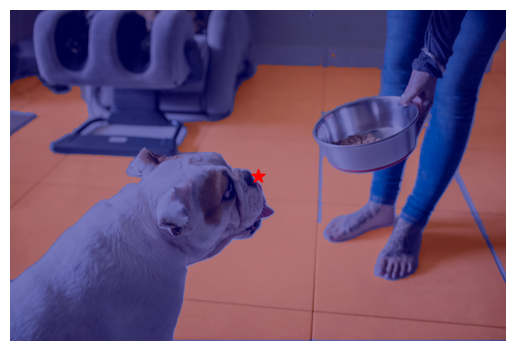

In [515]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.imshow(best, alpha=0.5, cmap='jet')
plt.scatter([click_x/scale], [click_y/scale], c='red', s=100, marker='*')
plt.axis('off'); plt.show()

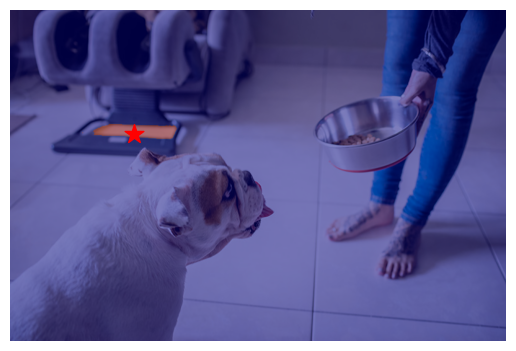

In [516]:
# Pick the point in ORIGINAL image coordinates first (look at your image, pick the dog's face)
orig_click_x, orig_click_y = 200, 200      # adjust by eye to land on the dog

# Convert to resized space for the model
resized_click_x = orig_click_x * scale
resized_click_y = orig_click_y * scale

batched_input = [{
    "image": img_t,
    "original_size": (orig_h, orig_w),
    "point_coords": torch.tensor([[[resized_click_x, resized_click_y]]], dtype=torch.float).cuda(),
    "point_labels": torch.tensor([[1]]).cuda(),
}]

outputs = sam(batched_input, multimask_output=True)
masks = outputs[0]["masks"][0]
ious = outputs[0]["iou_predictions"][0]

# Visualize with the ORIGINAL coords for the star
plt.imshow(img)
plt.imshow(masks[ious.argmax()].cpu().numpy(), alpha=0.5, cmap='jet')
plt.scatter([orig_click_x], [orig_click_y], c='red', s=200, marker='*')
plt.axis('off'); plt.show()

In [517]:
for i in range(3):
    print(f"mask {i}: {masks[i].sum().item()} px, iou {ious[i]:.3f}")

mask 0: 13255 px, iou 0.690
mask 1: 8417 px, iou 0.717
mask 2: 2472 px, iou 0.914


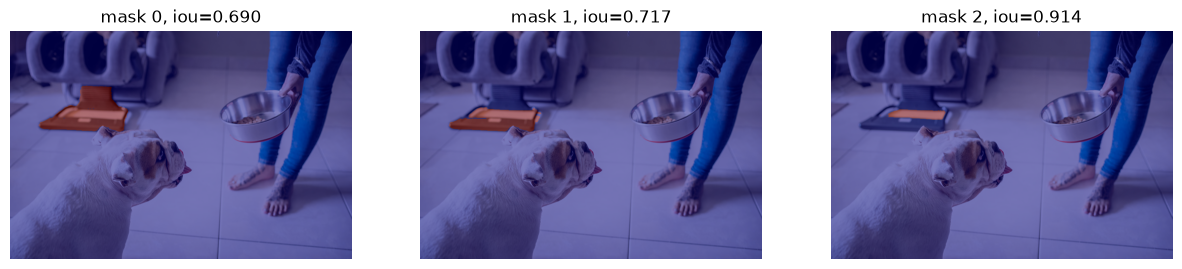

In [518]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(img)
    ax.imshow(masks[i].cpu().numpy(), alpha=0.5, cmap='jet')
    ax.set_title(f"mask {i}, iou={ious[i]:.3f}")
    ax.axis('off')
plt.show()

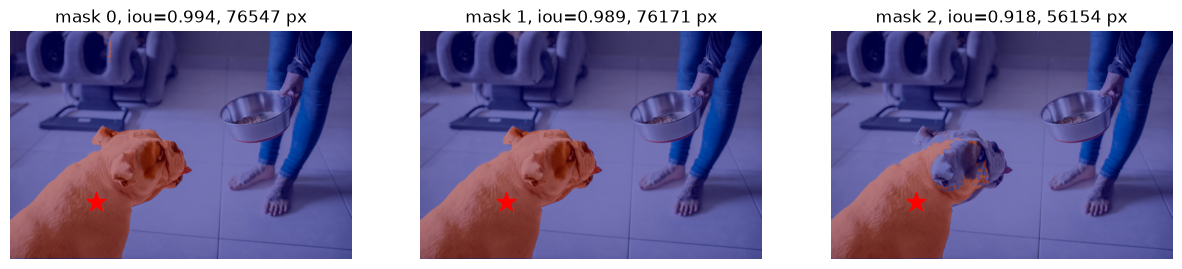

In [519]:
orig_click_x, orig_click_y = 200, 400     # dog's head

resized_click_x = orig_click_x * scale
resized_click_y = orig_click_y * scale

batched_input = [{
    "image": img_t,
    "original_size": (orig_h, orig_w),
    "point_coords": torch.tensor([[[resized_click_x, resized_click_y]]], dtype=torch.float).cuda(),
    "point_labels": torch.tensor([[1]]).cuda(),
}]

outputs = sam(batched_input, multimask_output=True)
masks = outputs[0]["masks"][0]
ious = outputs[0]["iou_predictions"][0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(img)
    ax.imshow(masks[i].cpu().numpy(), alpha=0.5, cmap='jet')
    ax.scatter([orig_click_x], [orig_click_y], c='red', s=200, marker='*')
    ax.set_title(f"mask {i}, iou={ious[i]:.3f}, {masks[i].sum().item()} px")
    ax.axis('off')
plt.show()

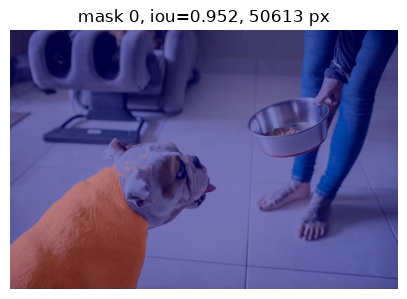

In [527]:
box = torch.tensor([[30.0, 250.0, 330.0, 534.0]]).cuda() * scale

batched_input = [{
    "image": img_t,
    "original_size": (orig_h, orig_w),
    "boxes": box,
}]
outputs = sam(batched_input, multimask_output=False)
masks = outputs[0]["masks"][0]
ious = outputs[0]["iou_predictions"][0]
n = masks.shape[0]                     # 1 when multimask_output=False
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]                       # make iterable when there's only one
for i, ax in enumerate(axes):
    ax.imshow(img)
    ax.imshow(masks[i].cpu().numpy(), alpha=0.5, cmap='jet')
    ax.set_title(f"mask {i}, iou={ious[i]:.3f}, {masks[i].sum().item()} px")
    ax.axis('off')
plt.show()
import matplotlib.patches as patches
x0, y0, x1, y1 = (box[0] / scale).cpu().numpy()    # back to original coords for display
ax.add_patch(patches.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, edgecolor='lime', lw=2))